In [4]:
from pathlib import Path

# CONFIG
PROJECT_FOLDER = Path(r"C:\\Users\\Alberto\\Desktop\\Electron tomography\\Project_ddw")
MRC_FILE_TO_RECONSTRUCT = Path(r"C:\\Users\\Alberto\\Desktop\\Electron tomography\\datasets\\2_squares\\sinograms\\sinogram_-50_5_50.mrc")

# ANGLES (see .mrc file)
FROM = -50
TO = 50
STEP = 5

DATA_DIR = PROJECT_FOLDER / "data"

TOMO_EVEN_FILE = DATA_DIR / "even_split.mrc"
TOMO_ODD_FILE = DATA_DIR / "odd_split.mrc"

## STEP 1 - SPLITTING TILT SERIES

In [5]:
# DATA CONFIG

TVM_ITERATIONS = 100
TV_WEIGHT = 3.0

Loading original 2D sinogram...
Corrected shape: (21, 362). Split into Even: (11, 362), Odd: (10, 362)

Reconstructing Image (Even slices)
Starting TVM reconstruction (100 iterations): 5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90  95  100 
Reconstructing Image (Odd slices)
Starting TVM reconstruction (100 iterations): 5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90  95  100 
Saving C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data\even_split.mrc...
Saving C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data\odd_split.mrc...
Step 1 Complete! TVM reconstructions successfully generated.
Image 0 shape: (362, 362), Image 1 shape: (362, 362)


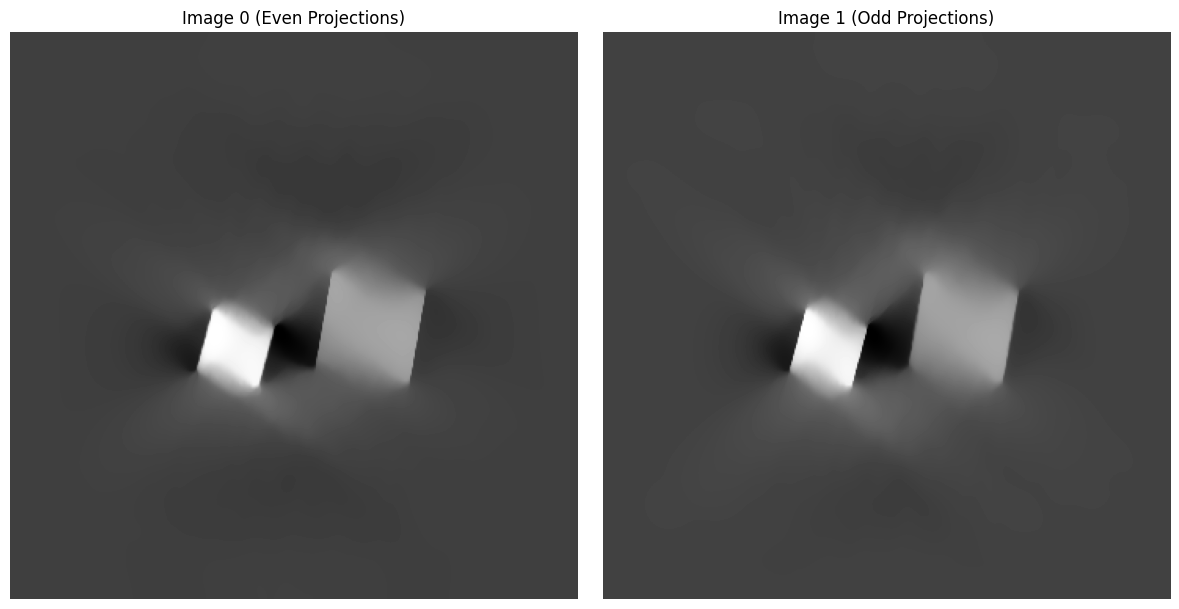

In [6]:
# TVM

import mrcfile
import numpy as np
from skimage.transform import iradon_sart 
from skimage.restoration import denoise_tv_chambolle
import matplotlib.pyplot as plt

def step_1(input_sinogram_mrc, angles_degrees, output_img0_path, output_img1_path, iterations=TVM_ITERATIONS, tv_weight=TV_WEIGHT):
    print("Loading original 2D sinogram...")
    with mrcfile.open(input_sinogram_mrc, permissive=True) as mrc:
        sinogram = np.squeeze(mrc.data.astype(np.float32))
        voxel_size = mrc.voxel_size

    # scikit-image expects the sinogram with angles as columns (pixels, angles)
    if sinogram.shape[1] == len(angles_degrees):
        sinogram = sinogram.T  
        
    if sinogram.shape[0] != len(angles_degrees):
        raise ValueError(f"Angle mismatch! Sinogram: {sinogram.shape[0]} rows, Angles: {len(angles_degrees)}")
    
    even_sinogram = sinogram[0::2].copy()
    odd_sinogram = sinogram[1::2].copy()
    
    even_angles = angles_degrees[0::2]
    odd_angles = angles_degrees[1::2]
    
    print(f"Corrected shape: {sinogram.shape}. Split into Even: {even_sinogram.shape}, Odd: {odd_sinogram.shape}")

    def reconstruct_tvm_2d(sino, angles, iters, weight):
        # scikit-image expects the sinogram with angles as columns (pixels, angles)
        sino_t = sino.T
        
        # Initialize an empty image
        reconstructed_img = np.zeros((sino_t.shape[0], sino_t.shape[0]), dtype=np.float32)
        
        print(f"Starting TVM reconstruction ({iters} iterations):", end="", flush=True)
        for i in range(iters):
            reconstructed_img = iradon_sart(sino_t, theta=angles, image=reconstructed_img)
            reconstructed_img = denoise_tv_chambolle(reconstructed_img, weight=weight)
            if (i + 1) % 5 == 0:
                print(f" {i + 1} ", end="", flush=True)
        
        return reconstructed_img.astype(np.float32)

    print("\nReconstructing Image (Even slices)")
    img0_data = reconstruct_tvm_2d(even_sinogram, even_angles, iters=iterations, weight=tv_weight)

    print("\nReconstructing Image (Odd slices)")
    img1_data = reconstruct_tvm_2d(odd_sinogram, odd_angles, iters=iterations, weight=tv_weight)

    print(f"\nSaving {output_img0_path}...")
    with mrcfile.new(output_img0_path, overwrite=True) as mrc0:
        mrc0.set_data(img0_data)
        mrc0.voxel_size = voxel_size
        
    print(f"Saving {output_img1_path}...")
    with mrcfile.new(output_img1_path, overwrite=True) as mrc1:
        mrc1.set_data(img1_data)
        mrc1.voxel_size = voxel_size

    print("Step 1 Complete! TVM reconstructions successfully generated.")


## FBP

#import mrcfile
#import numpy as np
#from skimage.transform import iradon  # Replaced iradon_sart with standard iradon
#
#def step_1(input_sinogram_mrc, angles_degrees, output_img0_path, output_img1_path):
#    print("Loading original 2D sinogram...")
#    with mrcfile.open(input_sinogram_mrc, permissive=True) as mrc:
#        sinogram = np.squeeze(mrc.data.astype(np.float32))
#        voxel_size = mrc.voxel_size
#
#    # Check and fix orientation (scikit-image expects shape: [angles, pixels])
#    if sinogram.shape[1] == len(angles_degrees):
#        sinogram = sinogram.T  
#        
#    if sinogram.shape[0] != len(angles_degrees):
#        raise ValueError(f"Angle mismatch! Sinogram: {sinogram.shape[0]} rows, Angles: {len(angles_degrees)}")
#
#    # 1. SPLIT THE SINOGRAM
#    even_sinogram = sinogram[0::2].copy()
#    odd_sinogram = sinogram[1::2].copy()
#    
#    even_angles = angles_degrees[0::2]
#    odd_angles = angles_degrees[1::2]
#    
#    print(f"Corrected shape: {sinogram.shape}. Split into Even: {even_sinogram.shape}, Odd: {odd_sinogram.shape}")
#
#    # 2. PERFORM FBP RECONSTRUCTION
#    def reconstruct_fbp_2d(sino, angles, filter_type='ramp'):
##        # scikit-image's iradon expects the sinogram with angles as columns (pixels, angles)
#        sino_t = sino.T
#        
#        # Perform standard Filtered Back-Projection
#        # circle=False ensures the reconstruction fills the square image rather than masking the corners
#        reconstructed_img = iradon(sino_t, theta=angles, filter_name=filter_type, circle=False)
#        
#        return reconstructed_img.astype(np.float32)
#
#    # Reconstruct Image 0 (Even)
#    print("\n--- Reconstructing Image 0 (Even) via FBP ---")
#    # 'ramp' is the standard mathematical filter for FBP, as used in the DeepDeWedge paper.
#    img0_data = reconstruct_fbp_2d(even_sinogram, even_angles, filter_type='ramp')
#    
#    # Reconstruct Image 1 (Odd)
#    print("\n--- Reconstructing Image 1 (Odd) via FBP ---")
#    img1_data = reconstruct_fbp_2d(odd_sinogram, odd_angles, filter_type='ramp')
#
#    # 3. SAVE THE 2D RECONSTRUCTIONS
#    print(f"\nSaving {output_img0_path}...")
#    with mrcfile.new(output_img0_path, overwrite=True) as mrc0:
#        mrc0.set_data(img0_data)
#        mrc0.voxel_size = voxel_size
#        
#    print(f"Saving {output_img1_path}...")
#    with mrcfile.new(output_img1_path, overwrite=True) as mrc1:
#        mrc1.set_data(img1_data)
#        mrc1.voxel_size = voxel_size
#
#    print("Step 1 Complete! FBP reconstructions successfully generated.")


def view_images(img0_path, img1_path):
    
    with mrcfile.open(img0_path, permissive=True) as mrc0:
        img0_data = np.squeeze(mrc0.data)
    with mrcfile.open(img1_path, permissive=True) as mrc1:
        img1_data = np.squeeze(mrc1.data)
        
    print(f"Image 0 shape: {img0_data.shape}, Image 1 shape: {img1_data.shape}")
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img0_data, cmap='gray')
    axes[0].set_title('Image 0 (Even Projections)')
    axes[0].axis('off')
    axes[1].imshow(img1_data, cmap='gray')
    axes[1].set_title('Image 1 (Odd Projections)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


my_angles = np.arange(FROM, TO+1, STEP) 
step_1(MRC_FILE_TO_RECONSTRUCT, my_angles, TOMO_EVEN_FILE, TOMO_ODD_FILE)
view_images(TOMO_EVEN_FILE, TOMO_ODD_FILE)

## STEP 2 - MODEL FITTING

In [7]:
# TRAINING CONFIG

SUBTOMO_SIZE = 128
# Patch size
STRIDES_2D = [4, 4]
# X and Y stride

LR = 1e-4
EPOCHS = 200
BATCH = 16


In [8]:
# PRE STEP 2 - DATA PREPARATION

import os
from pathlib import Path
from scripts.prepare_data import prepare_data

def run_test():
    print("Starting DeepDeWedge 2D Data Preparation Test...")
    
    if not TOMO_EVEN_FILE.exists() or not TOMO_ODD_FILE.exists():
        print("\n[ERROR] Input files not found!")
        print("Please update TOMO0_FILE and TOMO1_FILE variables to point to your actual .mrc files.")
        print(f"Currently looking for:\n  - {TOMO_EVEN_FILE}\n  - {TOMO_ODD_FILE}")
        return

    prepare_data(
        tomo0_files=[TOMO_EVEN_FILE],
        tomo1_files=[TOMO_ODD_FILE],
        subtomo_size=SUBTOMO_SIZE,
        val_fraction=0.1,
        mask_files=[],
        subtomo_extraction_strides=STRIDES_2D, 
        pad_before_subtomo_extraction=True,
        extract_larger_subtomos_for_rotating=True,
        standardize_full_tomos=True,
        project_dir=DATA_DIR,
        overwrite=True,
        seed=42,
        verbose=True
    )
    
    print(f"\nTest complete! Check the '{DATA_DIR}/subtomos' folder to see your extracted .pt files.")

run_test()

Starting DeepDeWedge 2D Data Preparation Test...
Saving all subtomograms to 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data/subtomos'.
Removing existing subtomogram directory 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data/subtomos'.
Starting subtomogram extraction from 1 tomogram(s).
Standardizing tomogram 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data\even_split.mrc' before extracting sub-tomograms.
Done with sub-tomogram extraction.
Saved a total of 1988 sub-tomograms for model fitting to 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data/subtomos/fitting_subtomos'.
Saved a total of 221 sub-tomograms for validation to 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data/subtomos/val_subtomos'.

Test complete! Check the 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data/subtomos' folder to see your extracted .pt files.


In [9]:
# MODEL FITTING

import os
from scripts.fit_model import fit_model


unet_params = {
    "in_chans": 1,
    "out_chans": 1,
    "chans": 32,
    "num_downsample_layers": 3,
    "drop_prob": 0.3, 
    "residual": True
}

adam_params = {
    "lr": LR
}

mw_angle = (360-TO*4)/2

def run_model_fitting():
    print("Starting DeepDeWedge 2D Model Fitting Test...")
    
    fit_model(
        unet_params_dict=unet_params,
        adam_params_dict=adam_params,
        num_epochs=EPOCHS,
        batch_size=BATCH,
        subtomo_size=SUBTOMO_SIZE,
        mw_angle=mw_angle,
        gpu=[0],
        num_workers=4,
        project_dir=PROJECT_FOLDER,
        logger="csv",
        check_val_every_n_epochs=1,
        update_subtomo_missing_wedges_every_n_epochs=10,
        save_model_every_n_epochs=50,
        save_n_models_with_lowest_fitting_loss=1,
        save_n_models_with_lowest_val_loss=1,
        distributed_backend="nccl",
        seed=42
    )
    
    print(f"\nFitting Test complete! Check the '{PROJECT_FOLDER}/logs' folder for your checkpoints.")

if __name__ == "__main__":
    run_model_fitting()

Global seed set to 42


Starting DeepDeWedge 2D Model Fitting Test...
Saving logs and model checkpoints to 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/logs/version_1'


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation DataLoader 0:  57%|█████▋    | 8/14 [00:00<00:00, 19.15it/s]

c:\Users\Alberto\Desktop\Electron tomography\tomo_venv\Lib\site-packages\pytorch_lightning\utilities\data.py:85: UserWarning: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
  warning_cache.warn(


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type   | Params
--------------------------------
0 | unet | Unet2D | 2.3 M 
--------------------------------
2.3 M     Trainable params
2         Non-trainable params
2.3 M     Total params
9.115     Total estimated model params size (MB)


Training: 0it [00:00, ?it/s]                                               

Computing model-input normalization statistics:  74%|███████▎  | 92/125 [00:06<00:02, 14.92it/s]


Fitting Test complete! Check the 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/logs' folder for your checkpoints.



c:\Users\Alberto\Desktop\Electron tomography\tomo_venv\Lib\site-packages\pytorch_lightning\trainer\call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


## STEP 3 - TOMOGRAM REFINEMENT AND VISUALIZATION

In [10]:
MODEL_PATH = PROJECT_FOLDER / "logs/version_0/checkpoints/val_loss/epoch=22-val_loss=1.00037.ckpt"

In [14]:
from pathlib import Path
from scripts.refine_tomogram import refine_tomogram

def run_test():
    print("Starting Final 2D Tomogram Refinement...")

    mw_angle = (360-TO*4)/2
    
    refine_tomogram(
        tomo0_files=[TOMO_EVEN_FILE],
        tomo1_files=[TOMO_ODD_FILE],
        model_checkpoint_file=MODEL_PATH,
        subtomo_size=SUBTOMO_SIZE,
        mw_angle=mw_angle,
        subtomo_overlap=SUBTOMO_SIZE // 3,
        standardize_full_tomos=True,
        recompute_normalization=True,
        batch_size=BATCH,
        project_dir=PROJECT_FOLDER,
        num_workers=4,
        gpu=[0]
    )
    
    print(f"\nRefinement Complete! Check '{PROJECT_FOLDER}/refined_tomograms' for your final image.")

if __name__ == "__main__":
    run_test()

Starting Final 2D Tomogram Refinement...
Standardizing tomogram 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\data\even_split.mrc' before extracting sub-tomograms.


Refining tomo1: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it]

Saving refined tomogram to C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/refined_tomograms/even_split+odd_split_refined.mrc
File 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/refined_tomograms/even_split+odd_split_refined.mrc' already exists! Moving it to 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/refined_tomograms/even_split+odd_split_refined.mrc~'

Refinement Complete! Check 'C:\Users\Alberto\Desktop\Electron tomography\Project_ddw/refined_tomograms' for your final image.


Loading C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\refined_tomograms\even_split+odd_slipt_refined.mrc...
Refined image shape: (362, 362)


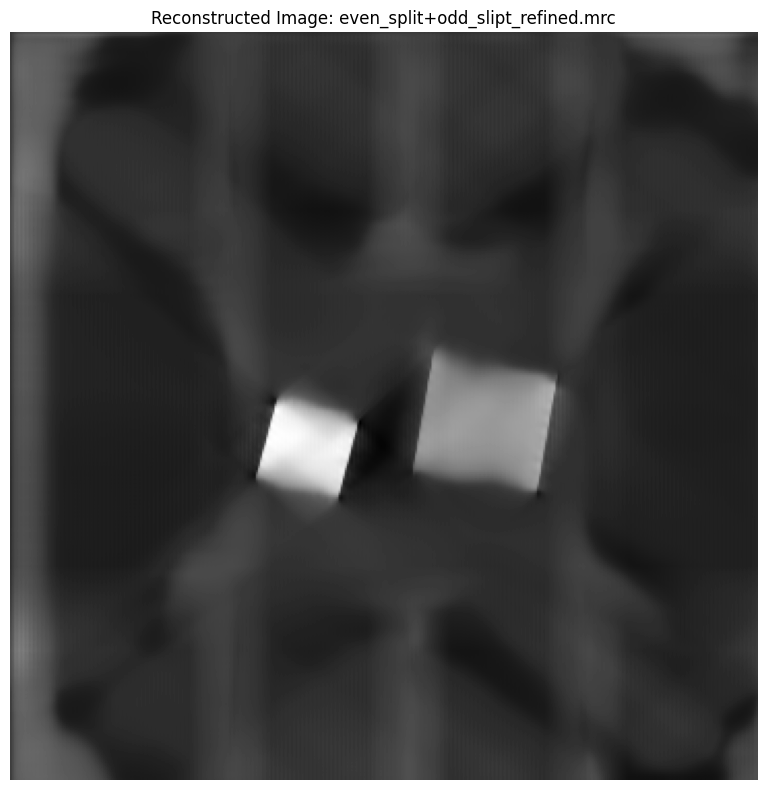

In [ ]:
# Show refined image

def view_image(refined_path):
    print(f"Loading {refined_path}...")
    
    with mrcfile.open(refined_path, permissive=True) as mrc:
        img_data = np.squeeze(mrc.data)
        
    print(f"Refined image shape: {img_data.shape}")
        
    plt.figure(figsize=(8, 8))
    plt.imshow(img_data, cmap='gray')
    plt.title(f'Reconstructed Image: {Path(refined_path).name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

view_image(r"C:\Users\Alberto\Desktop\Electron tomography\Project_ddw\refined_tomograms\even_split+odd_slipt_refined.mrc")